<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-40-roc-curve-auc-threshold-tuning?scriptVersionId=345396335" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a1628 0%, #0f2744 50%, #0a1e38 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #1a3a5c;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 40</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">📈 ROC Curve, AUC &amp; Threshold Tuning</h1>
  <p style="color: #7cb9e8; font-size: 16px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">Going beyond a single metric — plotting the Precision-Recall tradeoff across every possible threshold, computing AUC, and comparing models on a common ground regardless of the decision threshold chosen.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a3a5c; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #0ea5e9; font-size: 20px; font-weight: 700;">ROC Curve</div>
      <div style="color: #7cb9e8; font-size: 12px; margin-top: 2px;">TPR vs FPR at all thresholds</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a3a5c; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #0ea5e9; font-size: 20px; font-weight: 700;">AUC Score</div>
      <div style="color: #7cb9e8; font-size: 12px; margin-top: 2px;">Single number summary (0.5 → 1.0)</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a3a5c; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #0ea5e9; font-size: 20px; font-weight: 700;">LR vs SVM</div>
      <div style="color: #7cb9e8; font-size: 12px; margin-top: 2px;">Model comparison via AUC</div>
    </div>
  </div>
</div>

<div style="background: #061020; border-left: 5px solid #0ea5e9; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #1a3a5c; border-left: 5px solid #0ea5e9;">
  <h2 style="color: #0ea5e9; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #38bdf8; line-height: 2.1; font-size: 14px;">
    <li><a href='#why' style='color: #38bdf8; text-decoration: none;'>Why ROC Curve? — The Threshold Problem</a></li>
    <li><a href='#tpr-fpr' style='color: #38bdf8; text-decoration: none;'>TPR &amp; FPR — Benefit vs Cost</a></li>
    <li><a href='#roc-explained' style='color: #38bdf8; text-decoration: none;'>What the ROC Curve Shows</a></li>
    <li><a href='#auc' style='color: #38bdf8; text-decoration: none;'>AUC — Area Under the Curve</a></li>
    <li><a href='#imports' style='color: #38bdf8; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #38bdf8; text-decoration: none;'>Dataset — Healthcare Diabetes</a></li>
    <li><a href='#model' style='color: #38bdf8; text-decoration: none;'>Training Logistic Regression</a></li>
    <li><a href='#proba' style='color: #38bdf8; text-decoration: none;'>predict_proba — Getting Probability Scores</a></li>
    <li><a href='#roc1' style='color: #38bdf8; text-decoration: none;'>Plotting the ROC Curve</a></li>
    <li><a href='#optimal' style='color: #38bdf8; text-decoration: none;'>Finding the Optimal Threshold</a></li>
    <li><a href='#auc-plot' style='color: #38bdf8; text-decoration: none;'>ROC Curve with AUC Score</a></li>
    <li><a href='#compare' style='color: #38bdf8; text-decoration: none;'>Model Comparison — Logistic Regression vs SVM</a></li>
  </ol>
</div>

<a id='why'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Why ROC Curve? — The Threshold Problem</h2>
</div>

In the last episode we evaluated classifiers using a **fixed threshold of 0.5** — if the model predicted probability ≥ 0.5, we called it positive. But 0.5 is an arbitrary choice. Different applications need different thresholds:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 20px 0;">
  <div style="background: #061020; border: 1px solid #1a3a5c; border-top: 3px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 16px 18px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🏥 Medical Screening</div>
    <div style="color: #7cb9e8; font-size: 13px; line-height: 1.7;">Missing a sick patient is catastrophic. Set threshold low (e.g. 0.2) to catch more positives, accepting more false alarms. <strong style='color:#e0f0ff;'>Prioritise Recall.</strong></div>
  </div>
  <div style="background: #061020; border: 1px solid #1a3a5c; border-top: 3px solid #f0a500; border-radius: 0 0 8px 8px; padding: 16px 18px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📧 Spam Filter</div>
    <div style="color: #7cb9e8; font-size: 13px; line-height: 1.7;">Blocking a legitimate email is costly. Set threshold high (e.g. 0.8) to only block obvious spam. <strong style='color:#e0f0ff;'>Prioritise Precision.</strong></div>
  </div>
</div>

The **ROC curve** solves this by plotting model performance at **every possible threshold** simultaneously — giving you a complete picture of the tradeoff, not just a snapshot at 0.5.

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 10px; padding: 18px 24px; margin: 16px 0; font-size: 14px; color: #7cb9e8;">
  <strong style="color: #0ea5e9;">💡 Key Insight:</strong> Two models with the same accuracy at threshold=0.5 can have very different ROC curves. The ROC curve reveals which model is <em>fundamentally better</em> at discriminating classes — independent of the threshold chosen.
</div>

<a id='tpr-fpr'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">TPR &amp; FPR — Benefit vs Cost</h2>
</div>

The ROC curve plots two quantities against each other. Each comes directly from the confusion matrix:

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 12px; padding: 24px 32px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 28px;">
    <div style="border-right: 1px solid #1a3a5c; padding-right: 28px;">
      <div style="color: #2ecc71; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; font-weight: 700; margin-bottom: 10px;">✅ TPR — True Positive Rate (BENEFIT)</div>
      <div style="color: #e0f0ff; font-size: 18px; font-family: Georgia, serif; margin-bottom: 8px;">TPR = TP / (TP + FN)</div>
      <div style="color: #7cb9e8; font-size: 13px; line-height: 1.7;">
        Also called <strong style='color:#e0f0ff;'>Recall / Sensitivity</strong>.<br/>
        "Of all patients who actually have diabetes, what fraction did we correctly identify?"<br/><br/>
        <strong style='color:#2ecc71;'>High TPR = catching most real positives → benefit</strong>
      </div>
    </div>
    <div>
      <div style="color: #e74c3c; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; font-weight: 700; margin-bottom: 10px;">❌ FPR — False Positive Rate (COST)</div>
      <div style="color: #e0f0ff; font-size: 18px; font-family: Georgia, serif; margin-bottom: 8px;">FPR = FP / (FP + TN)</div>
      <div style="color: #7cb9e8; font-size: 13px; line-height: 1.7;">
        Also called <strong style='color:#e0f0ff;'>Fall-out / 1 − Specificity</strong>.<br/>
        "Of all healthy patients, what fraction did we wrongly flag as diabetic?"<br/><br/>
        <strong style='color:#e74c3c;'>High FPR = many false alarms → cost</strong>
      </div>
    </div>
  </div>
  <div style="margin-top: 18px; padding-top: 14px; border-top: 1px solid #1a3a5c; color: #0ea5e9; font-size: 14px; text-align: center; font-family: Georgia, serif;">
    The ROC curve plots: &nbsp; <strong>TPR (y-axis) vs FPR (x-axis)</strong> &nbsp; as threshold varies from 1 → 0
  </div>
</div>

<a id='roc-explained'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">What the ROC Curve Shows</h2>
</div>

As you lower the threshold from 1 to 0, more samples get predicted positive. Both TPR and FPR increase — the ROC curve traces this path:

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 20px 0;">
  <div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px; text-align: center;">
    <div style="font-size: 28px; margin-bottom: 8px;">📍</div>
    <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Point (0, 0)</div>
    <div style="color: #7cb9e8; font-size: 12px; line-height: 1.6;">Threshold = 1.0<br/>Predicts nothing positive.<br/>TPR=0, FPR=0</div>
  </div>
  <div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px; text-align: center;">
    <div style="font-size: 28px; margin-bottom: 8px;">📍</div>
    <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Point (1, 1)</div>
    <div style="color: #7cb9e8; font-size: 12px; line-height: 1.6;">Threshold = 0.0<br/>Predicts everything positive.<br/>TPR=1, FPR=1</div>
  </div>
  <div style="background: #061020; border: 1px solid #2ecc71; border-radius: 10px; padding: 16px; text-align: center;">
    <div style="font-size: 28px; margin-bottom: 8px;">🎯</div>
    <div style="color: #2ecc71; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Point (0, 1)</div>
    <div style="color: #7cb9e8; font-size: 12px; line-height: 1.6;">Perfect classifier!<br/>TPR=1, FPR=0<br/>No false alarms, catches all positives</div>
  </div>
</div>

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 10px; padding: 18px 24px; margin: 16px 0;">
  <div style="color: #7cb9e8; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 12px;">The Diagonal — Random Classifier Baseline</div>
  <div style="color: #e0f0ff; font-size: 14px; line-height: 1.7;">
    The dashed diagonal line from (0,0) to (1,1) represents a <strong>random classifier</strong> — it achieves TPR = FPR at all thresholds (no better than flipping a coin). Any model whose ROC curve lies <strong style='color:#0ea5e9;'>above this diagonal</strong> is better than random. The further the curve bows toward the top-left corner, the better.
  </div>
</div>

<a id='auc'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">AUC — Area Under the Curve</h2>
</div>

The **AUC (Area Under the ROC Curve)** measures the entire two-dimensional area underneath the ROC curve from (0,0) to (1,1). It provides a single aggregate number summarising performance **across all possible classification thresholds** — making model comparison threshold-independent.

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 12px; padding: 24px 32px; margin: 20px 0;">
  <div style="color: #7cb9e8; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">AUC Score Interpretation</div>
  <div style="display: flex; flex-direction: column; gap: 12px;">
    <div style="display: flex; align-items: center; gap: 16px;">
      <div style="background: #2ecc71; border-radius: 6px; padding: 6px 14px; font-weight: 700; color: #0a1628; font-size: 15px; min-width: 80px; text-align: center;">AUC = 1</div>
      <div style="color: #7cb9e8; font-size: 13px;"><strong style='color:#2ecc71;'>Perfect discrimination</strong> — model correctly classifies all positive and negative instances at some threshold. Ideal but rare in practice.</div>
    </div>
    <div style="display: flex; align-items: center; gap: 16px;">
      <div style="background: #0ea5e9; border-radius: 6px; padding: 6px 14px; font-weight: 700; color: #0a1628; font-size: 15px; min-width: 80px; text-align: center;">0.7–0.9</div>
      <div style="color: #7cb9e8; font-size: 13px;"><strong style='color:#0ea5e9;'>Good to excellent</strong> — meaningful discrimination ability. Most real-world models aim for this range.</div>
    </div>
    <div style="display: flex; align-items: center; gap: 16px;">
      <div style="background: #f0a500; border-radius: 6px; padding: 6px 14px; font-weight: 700; color: #0a1628; font-size: 15px; min-width: 80px; text-align: center;">AUC = 0.5</div>
      <div style="color: #7cb9e8; font-size: 13px;"><strong style='color:#f0a500;'>No discrimination ability</strong> — as good as random guessing. ROC curve is the diagonal line.</div>
    </div>
    <div style="display: flex; align-items: center; gap: 16px;">
      <div style="background: #e74c3c; border-radius: 6px; padding: 6px 14px; font-weight: 700; color: white; font-size: 15px; min-width: 80px; text-align: center;">AUC = 0</div>
      <div style="color: #7cb9e8; font-size: 13px;"><strong style='color:#e74c3c;'>Perfectly wrong</strong> — classifies all positives as negative and vice versa. Flip its predictions and you get a perfect model!</div>
    </div>
  </div>
</div>

<div style="background: #0a1e35; border: 1px solid #1a3a5c; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #7cb9e8;">
  <strong style="color: #0ea5e9;">🔑 Why AUC for model comparison:</strong> Two models with the same accuracy or F1 at threshold=0.5 can have very different AUCs. AUC tells you which model has better <em>inherent discriminative ability</em> — regardless of the operational threshold you later choose. It's the preferred metric for comparing classifiers.
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)

<a id='data'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Dataset — Healthcare Diabetes</h2>
</div>

The **Pima Indians Diabetes dataset** contains medical measurements for 768 female patients. The binary target is whether the patient has diabetes (`1`) or not (`0`). This is a perfect ROC-AUC use case — class imbalance (~35% positive) means accuracy alone is misleading.

In [2]:
data = pd.read_csv('/kaggle/input/datasets/nanditapore/healthcare-diabetes/Healthcare-Diabetes.csv')

print(f"Shape  : {data.shape}")
print(f"Nulls  : {data.isnull().sum().sum()}")
print(f"\nClass distribution:")
vc = data['Outcome'].value_counts()
print(f"  No Diabetes (0) : {vc[0]}  ({vc[0]/len(data)*100:.1f}%)")
print(f"  Diabetes    (1) : {vc[1]}  ({vc[1]/len(data)*100:.1f}%)")

data.head()

Shape  : (2768, 10)
Nulls  : 0

Class distribution:
  No Diabetes (0) : 1816  (65.6%)
  Diabetes    (1) : 952  (34.4%)


,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Drop Id column — not a feature
X = data.drop(columns=['Outcome', 'Id'])
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Test class balance — 0: {(y_test==0).sum()}, 1: {(y_test==1).sum()}")

Train : (2076, 8)  |  Test : (692, 8)
Test class balance — 0: 452, 1: 240


<a id='model'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Training Logistic Regression</h2>
</div>

In [4]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred_default = model.predict(X_test)
print(f"Accuracy at default threshold (0.5): {accuracy_score(y_test, y_pred_default):.4f}")

Accuracy at default threshold (0.5): 0.7962


<a id='proba'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">predict_proba — Getting Probability Scores</h2>
</div>

`predict()` returns hard 0/1 labels using threshold=0.5. To draw the ROC curve, we need the **raw probability scores** — `predict_proba()` returns a (n_samples, 2) array where column 1 is the probability of the positive class. We use those scores to evaluate performance at every possible threshold.

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #7cb9e8;">
  <strong style="color: #0ea5e9;">Why probabilities, not labels?</strong> The ROC curve asks: "at threshold t, what is TPR and FPR?" — and sweeps t across every unique predicted probability. We need the raw scores to do this sweep; hard labels are already post-threshold and lose this information.
</div>

In [5]:
# predict_proba returns [[P(class=0), P(class=1)], ...]
# We take column 1 — probability of being diabetic
y_scores = model.predict_proba(X_test)[:, 1]

print(f"Score range : [{y_scores.min():.4f}, {y_scores.max():.4f}]")
print(f"\nSample of predicted probabilities:")
print(pd.Series(y_scores).describe().round(4).to_string())

Score range : [0.0048, 0.9947]

Sample of predicted probabilities:
count    692.0000
mean       0.3390
std        0.2597
min        0.0048
25%        0.1217
50%        0.2693
75%        0.5165
max        0.9947


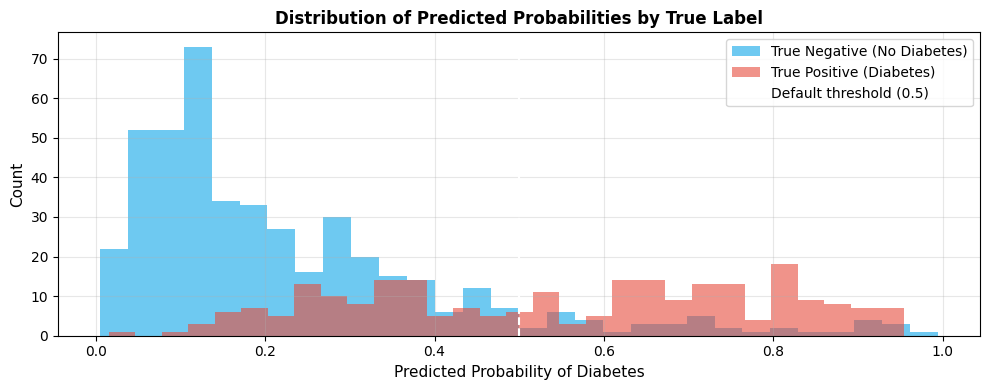

In [6]:
# Distribution of predicted probabilities — coloured by true label
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_scores[y_test == 0], bins=30, alpha=0.6, color='#0ea5e9', label='True Negative (No Diabetes)')
ax.hist(y_scores[y_test == 1], bins=30, alpha=0.6, color='#e74c3c', label='True Positive (Diabetes)')
ax.axvline(0.5, color='white', linewidth=1.5, linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Predicted Probability of Diabetes', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Predicted Probabilities by True Label', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #061020; border-left: 4px solid #0ea5e9; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #7cb9e8;">
  <strong style="color: #e0f0ff;">💡 Reading the histogram:</strong> A well-calibrated classifier pushes the two distributions apart — blue (no diabetes) peaks near 0, red (diabetes) peaks near 1. The overlap region is where errors happen. The ROC curve quantifies how well the model separates these distributions.
</div>

<a id='roc1'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Plotting the ROC Curve</h2>
</div>

`roc_curve()` returns three arrays:
- **`fpr`** — False Positive Rate at each threshold
- **`tpr`** — True Positive Rate at each threshold
- **`thresholds`** — the actual probability cutoffs used (sorted descending, first entry is `inf`)

Each point on the ROC curve corresponds to one threshold value — the curve is formed by connecting all these points.

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

print(f"Number of threshold points : {len(thresholds)}")
print(f"Threshold range            : [{thresholds[-1]:.4f}, {thresholds[1]:.4f}]  (first entry is inf)")

Number of threshold points : 312
Threshold range            : [0.0048, 0.9947]  (first entry is inf)


In [8]:
# Label every nth threshold to avoid clutter
n = 10
label_idx = np.arange(len(thresholds)) % n == 0

trace_roc = go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name='ROC curve',
    line=dict(color='#0ea5e9', width=2.5)
)
trace_pts = go.Scatter(
    x=fpr[label_idx], y=tpr[label_idx],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={t:.2f}" for t in thresholds[label_idx]],
    textposition='top center',
    marker=dict(color='#f0a500', size=8)
)
trace_diag = go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    name='Random classifier (AUC=0.5)',
    line=dict(dash='dash', color='#e74c3c', width=1.5)
)

fig = go.Figure(
    data=[trace_roc, trace_pts, trace_diag],
    layout=go.Layout(
        title=dict(text='ROC Curve — Logistic Regression on Diabetes Dataset', font=dict(size=15)),
        xaxis=dict(title='False Positive Rate (FPR)', range=[0, 1]),
        yaxis=dict(title='True Positive Rate (TPR)', range=[0, 1.02]),
        width=750, height=700,
        showlegend=True,
        legend=dict(x=0.6, y=0.1),
        plot_bgcolor='#061020',
        paper_bgcolor='#0a1628',
        font=dict(color='#e0f0ff')
    )
)
fig.show()

<a id='optimal'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Finding the Optimal Threshold</h2>
</div>

The **Youden's J statistic** (`TPR − FPR`) measures how far each point on the ROC curve is from the diagonal. The threshold that maximises this difference gives the best balance between benefit (TPR) and cost (FPR) — it's the point closest to the top-left corner.

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px 22px; margin: 14px 0; font-size: 13px; color: #7cb9e8;">
  <strong style="color: #0ea5e9;">⚠️ Important:</strong> This is the optimal threshold for <em>maximising overall performance</em> (equal weight to TPR and FPR). For medical applications you may want to weight Recall higher — set a lower threshold manually. The Youden method is a starting point, not a universal rule.
</div>

In [9]:
# Youden's J: maximise TPR - FPR
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr       = tpr[optimal_idx]
optimal_fpr       = fpr[optimal_idx]

print(f"Optimal threshold : {optimal_threshold:.4f}")
print(f"At this threshold → TPR = {optimal_tpr:.4f}  |  FPR = {optimal_fpr:.4f}")
print(f"Youden's J        : {optimal_tpr - optimal_fpr:.4f}")

# Compare default vs optimal threshold performance
y_pred_optimal = (y_scores >= optimal_threshold).astype(int)

print(f"\nDefault threshold (0.50) accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Optimal threshold ({optimal_threshold:.2f}) accuracy : {accuracy_score(y_test, y_pred_optimal):.4f}")

from sklearn.metrics import recall_score, precision_score
print(f"\n{'Metric':<15} {'Default (0.5)':>15} {'Optimal':>15}")
print("-" * 46)
for metric, fn in [('Accuracy', accuracy_score), ('Recall', recall_score), ('Precision', precision_score)]:
    print(f"{metric:<15} {fn(y_test, y_pred_default):>15.4f} {fn(y_test, y_pred_optimal):>15.4f}")

Optimal threshold : 0.3067
At this threshold → TPR = 0.8083  |  FPR = 0.2389
Youden's J        : 0.5694

Default threshold (0.50) accuracy : 0.7962
Optimal threshold (0.31) accuracy : 0.7775

Metric            Default (0.5)         Optimal
----------------------------------------------
Accuracy                 0.7962          0.7775
Recall                   0.5750          0.8083
Precision                0.7797          0.6424


In [10]:
# Visualise the optimal point on the ROC curve
fig_opt = go.Figure(
    data=[
        go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve',
                   line=dict(color='#0ea5e9', width=2.5)),
        go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random',
                   line=dict(dash='dash', color='#e74c3c', width=1.5)),
        go.Scatter(x=[optimal_fpr], y=[optimal_tpr], mode='markers+text',
                   name=f'Optimal threshold = {optimal_threshold:.3f}',
                   text=[f"  Threshold = {optimal_threshold:.3f}"],
                   textposition='middle right',
                   marker=dict(color='#2ecc71', size=14, symbol='star'))
    ],
    layout=go.Layout(
        title='ROC Curve — Optimal Threshold (Youden\'s J)',
        xaxis=dict(title='FPR', range=[0, 1]),
        yaxis=dict(title='TPR', range=[0, 1.02]),
        width=700, height=650,
        plot_bgcolor='#061020', paper_bgcolor='#0a1628',
        font=dict(color='#e0f0ff'),
        legend=dict(x=0.55, y=0.1)
    )
)
fig_opt.show()

<a id='auc-plot'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">ROC Curve with AUC Score</h2>
</div>

`roc_auc_score()` computes the AUC directly from the probability scores using numerical integration (trapezoidal rule). We include it in the legend label as convention.

In [11]:
roc_auc = roc_auc_score(y_test, y_scores)
print(f"AUC Score : {roc_auc:.4f}")

# Shade the area under the curve for visual impact
fig_auc = go.Figure(
    data=[
        go.Scatter(
            x=np.append(fpr, [1, 0]),
            y=np.append(tpr, [0, 0]),
            fill='toself', fillcolor='rgba(14,165,233,0.15)',
            line=dict(color='rgba(0,0,0,0)'),
            name='AUC area', showlegend=False
        ),
        go.Scatter(x=fpr, y=tpr, mode='lines',
                   name=f'Logistic Regression (AUC = {roc_auc:.3f})',
                   line=dict(color='#0ea5e9', width=2.5)),
        go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                   name='Random (AUC = 0.5)',
                   line=dict(dash='dash', color='#e74c3c', width=1.5)),
        go.Scatter(x=[optimal_fpr], y=[optimal_tpr], mode='markers',
                   name=f'Optimal thr = {optimal_threshold:.3f}',
                   marker=dict(color='#2ecc71', size=12, symbol='star'))
    ],
    layout=go.Layout(
        title=f'ROC Curve with AUC = {roc_auc:.3f}',
        xaxis=dict(title='False Positive Rate', range=[0, 1]),
        yaxis=dict(title='True Positive Rate', range=[0, 1.02]),
        width=750, height=700,
        plot_bgcolor='#061020', paper_bgcolor='#0a1628',
        font=dict(color='#e0f0ff'),
        legend=dict(x=0.45, y=0.08)
    )
)
fig_auc.show()

AUC Score : 0.8592


<a id='compare'></a>
<div style="border-bottom: 2px solid #0ea5e9; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #0ea5e9; color: #0a1628; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 12</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Model Comparison — Logistic Regression vs SVM</h2>
</div>

The ROC curve's most powerful use is **comparing multiple models on the same plot**. Whichever model's curve lies consistently higher and further left has better discriminative ability — regardless of threshold.

<div style="background: #061020; border: 1px solid #1a3a5c; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #7cb9e8;">
  <strong style="color: #0ea5e9;">⚠️ Note on SVM:</strong> SVM is sensitive to feature scale — large-magnitude features (like Glucose: 0–200) dominate the kernel computation. We apply <code>StandardScaler</code> before fitting SVM. Logistic Regression is less sensitive because its loss function handles scale implicitly, so we fit it on unscaled data as before.
</div>

In [12]:
# Scale features for SVM
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

# Logistic Regression (already fitted — reuse)
lr_model  = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:, 1]

# SVM with probability=True to enable predict_proba
svm_model  = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:, 1]

# ROC curve data
lr_fpr,  lr_tpr,  _  = roc_curve(y_test, lr_scores)
svm_fpr, svm_tpr, _  = roc_curve(y_test, svm_scores)

lr_auc  = roc_auc_score(y_test, lr_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

print(f"Logistic Regression AUC : {lr_auc:.4f}")
print(f"SVM                 AUC : {svm_auc:.4f}")
print(f"\nLR  Accuracy  : {accuracy_score(y_test, lr_model.predict(X_test)):.4f}")
print(f"SVM Accuracy  : {accuracy_score(y_test, svm_model.predict(X_test_scaled)):.4f}")

Logistic Regression AUC : 0.8592
SVM                 AUC : 0.9204

LR  Accuracy  : 0.7962
SVM Accuracy  : 0.8338


In [13]:
fig_compare = go.Figure(
    data=[
        go.Scatter(x=lr_fpr,  y=lr_tpr,  mode='lines',
                   name=f'Logistic Regression (AUC = {lr_auc:.3f})',
                   line=dict(color='#0ea5e9', width=2.5)),
        go.Scatter(x=svm_fpr, y=svm_tpr, mode='lines',
                   name=f'SVM (AUC = {svm_auc:.3f})',
                   line=dict(color='#f0a500', width=2.5)),
        go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                   name='Random (AUC = 0.5)',
                   line=dict(dash='dash', color='#e74c3c', width=1.5)),
    ],
    layout=go.Layout(
        title='ROC Curve Comparison — Logistic Regression vs SVM',
        xaxis=dict(title='False Positive Rate', range=[0, 1]),
        yaxis=dict(title='True Positive Rate', range=[0, 1.02]),
        width=800, height=700,
        plot_bgcolor='#061020', paper_bgcolor='#0a1628',
        font=dict(color='#e0f0ff'),
        legend=dict(x=0.45, y=0.08)
    )
)
fig_compare.show()

In [14]:
# Full classification report comparison
print("=" * 55)
print("  LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, lr_model.predict(X_test),
                             target_names=['No Diabetes', 'Diabetes']))

print("=" * 55)
print("  SVM")
print("=" * 55)
print(classification_report(y_test, svm_model.predict(X_test_scaled),
                             target_names=['No Diabetes', 'Diabetes']))

  LOGISTIC REGRESSION
              precision    recall  f1-score   support

 No Diabetes       0.80      0.91      0.85       452
    Diabetes       0.78      0.57      0.66       240

    accuracy                           0.80       692
   macro avg       0.79      0.74      0.76       692
weighted avg       0.79      0.80      0.79       692

  SVM
              precision    recall  f1-score   support

 No Diabetes       0.83      0.93      0.88       452
    Diabetes       0.84      0.65      0.73       240

    accuracy                           0.83       692
   macro avg       0.84      0.79      0.80       692
weighted avg       0.83      0.83      0.83       692



<div style="background: linear-gradient(135deg, #0a1628 0%, #0f2744 100%); border: 1px solid #1a3a5c; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary &amp; Key Takeaways</h2>
  <p style="color: #7cb9e8; font-size: 13px; margin: 0 0 20px 0;">What you should take away from ROC-AUC analysis.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(14,165,233,0.08); border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📈 ROC Curve</div>
      <div style="color: #7cb9e8; font-size: 12px; line-height: 1.7;">Plots TPR vs FPR at every threshold. Hugging the top-left = better. The diagonal = random baseline. Use it to <strong style='color:#e0f0ff;'>understand the benefit-cost tradeoff</strong> of your classifier.</div>
    </div>
    <div style="background: rgba(14,165,233,0.08); border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📐 AUC Score</div>
      <div style="color: #7cb9e8; font-size: 12px; line-height: 1.7;">Single number (0.5–1.0). AUC=1 = perfect, AUC=0.5 = random. <strong style='color:#e0f0ff;'>Use AUC to compare models</strong> in a threshold-independent way — especially on imbalanced data.</div>
    </div>
    <div style="background: rgba(14,165,233,0.08); border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🎯 Optimal Threshold</div>
      <div style="color: #7cb9e8; font-size: 12px; line-height: 1.7;">Youden's J (max TPR−FPR) finds the balanced optimal. For medical tasks, lower the threshold to boost Recall. <strong style='color:#e0f0ff;'>Don't blindly use 0.5.</strong></div>
    </div>
    <div style="background: rgba(14,165,233,0.08); border: 1px solid #1a3a5c; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #0ea5e9; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ SVM vs LR</div>
      <div style="color: #7cb9e8; font-size: 12px; line-height: 1.7;">SVM needs feature scaling; LR is more robust without it. On this dataset both achieve similar AUC — the ROC curve makes this comparison fair and visual. Always <strong style='color:#e0f0ff;'>scale before SVM.</strong></div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #1a3a5c; color: #7cb9e8; font-size: 12px;">
    Next up → <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-41-softmax-regression-multinomial-lr' style='text-decoration: none;'><strong style='color:#0ea5e9;'>🤖 ML 41 — Softmax Regression | Multinomial LR</strong>
  </div>
</div>